In [1]:
%pip install numpy
%pip install pandas
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
%pip install scikit-image
%pip install keras

  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached imageio-2.37.4-py3-none-any.whl.metadata (9.6 kB)
  Using cached tifffile-2026.9.9-py3-none-any.whl.metadata (33 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
    --------------------------------------- 0.3/11.9 MB ? eta -:--:--
   ------- -------------------------------- 2.1/11.9 MB 8.4 MB/s eta 0:00:02
   ----------- ---------------------------- 3.4/11.9 MB 7.7 MB/s eta 0:00:02
   ---------------- ----------------------- 5.0/11.9 MB 7.4 MB/s eta 0:00:01
   --------------------- ------------------ 6.3/11.9 MB 7.3 MB/s eta 0:00:01
   -------------------------- ------------- 7.9/11.9 MB 7.2 MB/s eta 0:00:01
   ------------------------------ --------- 9.2/11.9 MB 7.2 MB/s eta 0:00:01
   ------------------------------------ --- 10.7/11.9 MB 7.1 MB/s eta 0:00:01
   ---------------------------------------- 11.9/11.9 MB 

In [3]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # visualize satellite images
from skimage.io import imshow # visualize satellite images

In [53]:
import zipfile
import pandas as pd

print("Loading Training Data")

with zipfile.ZipFile('X_test_sat4.csv.zip', 'r') as z:
    with z.open('X_test_sat4.csv') as f:
        X_train = pd.read_csv(f, nrows=20)

print("Loaded 28 x 28 x 4 images")

Y_train = pd.read_csv('y_test_sat4.csv', nrows=20)

print("Loaded labels")

Loading Training Data
Loaded 28 x 28 x 4 images
Loaded labels


In [54]:
print(type(X_train))
print(type(Y_train))

print(
    'We have', X_train.shape[0],
    'examples and each example is a list of',
    X_train.shape[1],
    'numbers with',
    Y_train.shape[1],
    'possible classifications.'
)

<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>
We have 20 examples and each example is a list of 3136 numbers with 4 possible classifications.


In [12]:
import sys
print(sys.version)

%pip show keras
%pip show tensorflow

3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Name: keras
Version: 3.15.1
Summary: Multi-backend Keras
Home-page: 
Author: 
Author-email: Keras team <keras-users@googlegroups.com>
License: Apache License 2.0
Location: c:\Users\hecto\OneDrive\Escritorio\Laboral Extra\Laboral IPET\Practica Profesional II\Unidad Nº3\iappii\iappii\venv312\Lib\site-packages
Requires: absl-py, h5py, ml-dtypes, namex, numpy, optree, packaging, rich
Required-by: tensorflow
Note: you may need to restart the kernel to use updated packages.
Name: tensorflow
Version: 2.21.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: c:\Users\hecto\OneDrive\Escritorio\Laboral Extra\Laboral IPET\Practica Profesional II\Unidad Nº3\iappii\iappii\venv312\Lib\site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpc

In [55]:
X_train = X_train.to_numpy()
Y_train = Y_train.to_numpy()

In [56]:
X_train_img = X_train.reshape(-1, 28, 28, 4).astype(float)

print(X_train_img.shape)

(20, 28, 28, 4)


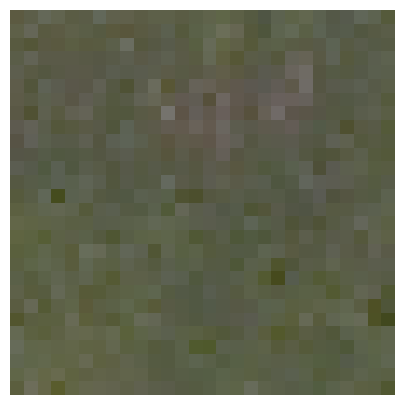

Grassland


In [59]:
import matplotlib.pyplot as plt

ix = 3

plt.figure(figsize=(5, 5))

plt.imshow(X_train_img[ix, :, :, 0:3] / 255.0)

plt.axis('off')
plt.show()

# Clasificación
if Y_train[ix, 0] == 1:
    print('Barren Land')
elif Y_train[ix, 1] == 1:
    print('Trees')
elif Y_train[ix, 2] == 1:
    print('Grassland')
else:
    print('Other')

In [72]:
X_train = X_train/255

In [73]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout

In [74]:
model = Sequential([
    Dense(4, input_shape=(3136,), activation='softmax')
])

c:\Users\hecto\OneDrive\Escritorio\Laboral Extra\Laboral IPET\Practica Profesional II\Unidad Nº3\iappii\iappii\venv312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [88]:
history = model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [89]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 4)              │        12,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,548 (49.02 KB)

 Trainable params: 12,548 (49.02 KB)

 Non-trainable params: 0 (0.00 B)

In [90]:
model.fit(X_train,Y_train,batch_size=32, epochs=5, verbose=1, validation_split=0.01)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 877ms/step - accuracy: 0.2632 - loss: 1.3863 - val_accuracy: 1.0000 - val_loss: 1.3858
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.3158 - loss: 1.3861 - val_accuracy: 1.0000 - val_loss: 1.3853
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.2632 - loss: 1.3859 - val_accuracy: 1.0000 - val_loss: 1.3848
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.2632 - loss: 1.3857 - val_accuracy: 1.0000 - val_loss: 1.3843
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.2632 - loss: 1.3856 - val_accuracy: 1.0000 - val_loss: 1.3837


In [67]:
preds = model.predict(X_train[-1:], verbose=1)
print(preds.shape)
print(preds[0])
print(np.argmax(preds[0]))
print(Y_train[-1:][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
(1, 4)
[0.12969288 0.13335986 0.25238746 0.48455968]
3
[1 0 0 0]


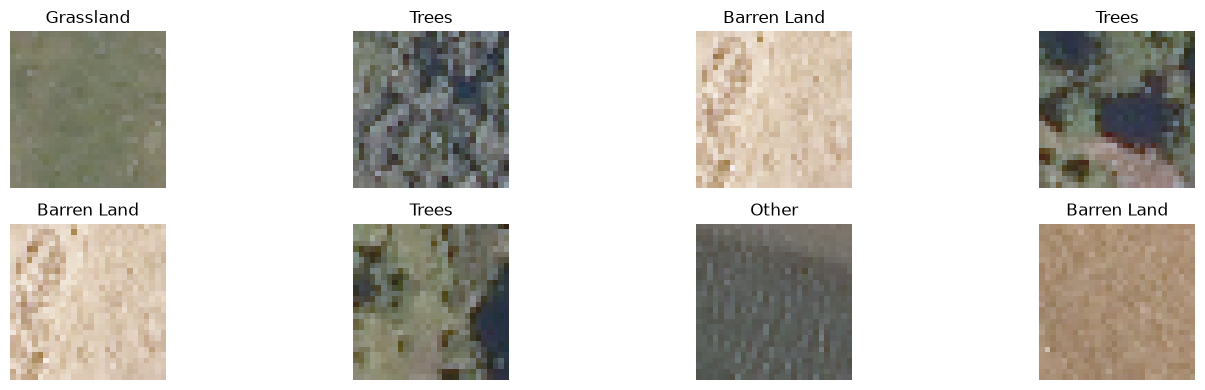

In [81]:
fig = plt.figure(figsize=(15, 4))

columns = 4
rows = 2

nombres = [
    'Barren Land',
    'Trees',
    'Grassland',
    'Other'
]

for i in range(columns * rows):

    # Índice aleatorio
    n = np.random.randint(X_train_img.shape[0])

    ax = fig.add_subplot(rows, columns, i + 1)

    # Obtener clase
    clase = np.argmax(Y_train[n])

    ax.set_title(nombres[clase])
    ax.axis('off')

    # Mostrar la imagen correspondiente a n
    ax.imshow(X_train_img[n, :, :, 0:3] / 255.0)

plt.tight_layout()
plt.show()

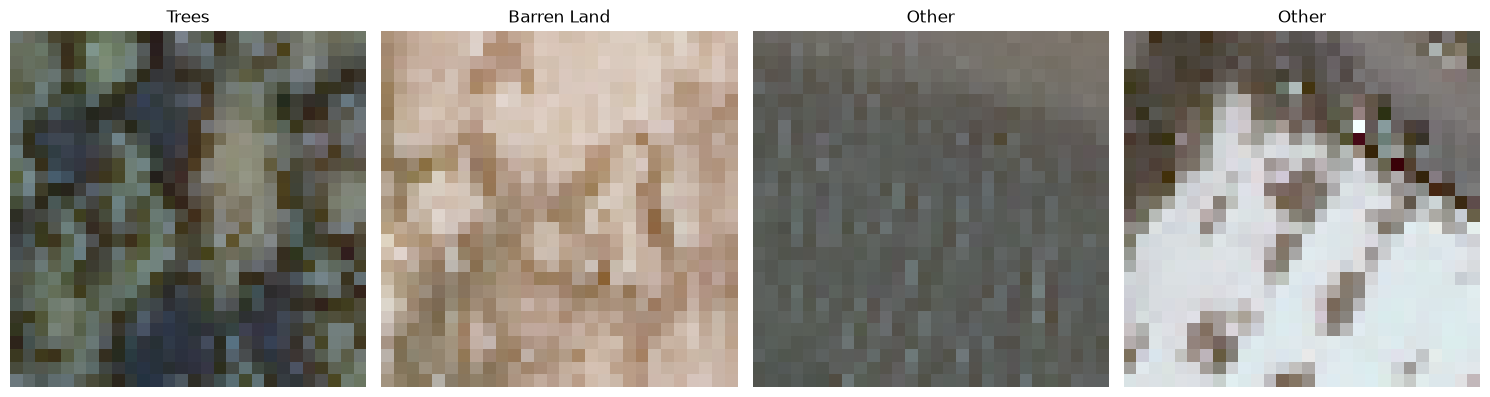

In [84]:
indices = np.random.choice(X_train_img.shape[0], 4, replace=False)
fig = plt.figure(figsize=(15, 4))
for i, n in enumerate(indices):
    ax = fig.add_subplot(1, 4, i + 1)
    clase = np.argmax(Y_train[n])
    ax.set_title(nombres[clase])
    ax.axis('off')
    ax.imshow(X_train_img[n, :, :, 0:3] / 255.0)
plt.tight_layout()
plt.show()